In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
# PARTIE 1 : RÉGRESSION LINÉAIRE SIMPLE
#  Charger le dataset: Données : house_area_price.xlsx (Area → Price)
# -----------------------------------------------------------------------------
housing = pd.read_excel(r'C:\Users\DELL\Downloads\house_area_price.xlsx')

In [15]:
# Étape 3 : Examiner les données
# -----------------------------------------------------------------------------
 
# Nombre de lignes et de colonnes
print("=== Dimensions du dataset ===")
print(housing.shape)
 
# 5 premières lignes
print("\n=== 5 premières lignes ===")
print(housing.head())
 
# Informations sur les colonnes (types, valeurs nulles)
print("\n=== Informations sur les colonnes ===")
print(housing.info())
 
# Statistiques descriptives
print("\n=== Statistiques descriptives ===")
print(housing.describe())
 
# Vérifier les lignes dupliquées
print("\n=== Lignes dupliquées ===")
print(housing.duplicated().sum())
 
# Vérifier les valeurs manquantes
print("\n=== Valeurs manquantes ===")
print(housing.isnull().sum())

=== Dimensions du dataset ===
(1000, 2)

=== 5 premières lignes ===
   Area         Price
0  1360  2.623829e+05
1  4272  9.852609e+05
2  3592  7.779774e+05
3   966  2.296989e+05
4  4926  1.041741e+06

=== Informations sur les colonnes ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Area    1000 non-null   int64  
 1   Price   1000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 15.8 KB
None

=== Statistiques descriptives ===
              Area         Price
count  1000.000000  1.000000e+03
mean   2815.422000  6.188610e+05
std    1255.514921  2.535681e+05
min     503.000000  1.116269e+05
25%    1749.500000  4.016482e+05
50%    2862.500000  6.282673e+05
75%    3849.500000  8.271413e+05
max    4999.000000  1.108237e+06

=== Lignes dupliquées ===
0

=== Valeurs manquantes ===
Area     0
Price    0
dtype: int64


In [16]:
# Étape 4 : Diviser les données en train (80%) et test (20%)
# -----------------------------------------------------------------------------
X = housing[['Area']]
y = housing['Price']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

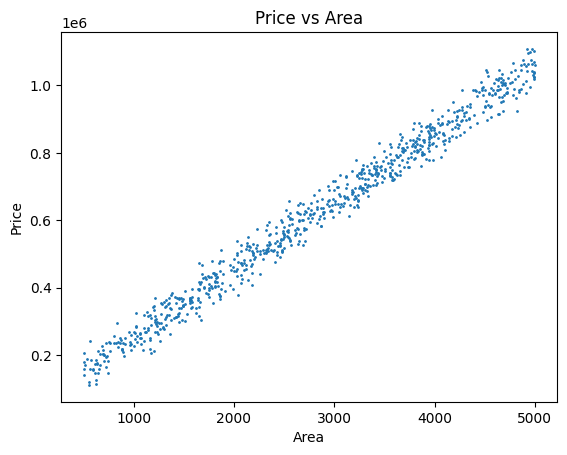

In [17]:
# Étape 5 : Visualiser les données d'entraînement
# -----------------------------------------------------------------------------
plt.scatter(X_train['Area'], y_train, s=1)
plt.title('Price vs Area')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()


=== Paramètres du modèle ===
Intercept (β0) : 54229.05860489223
Coefficient (β1) : [200.55687687]


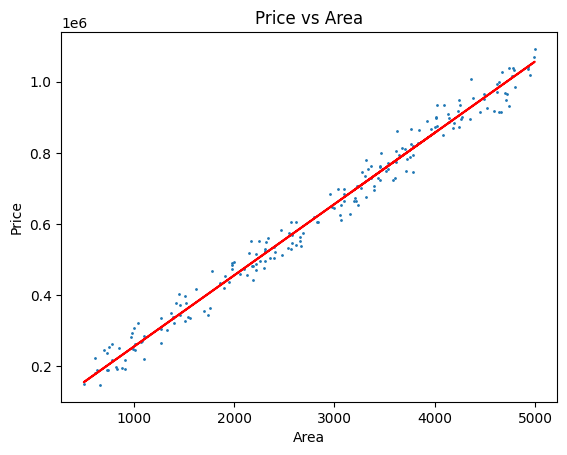

In [18]:
# Étape 6 : Entraîner le modèle
# -----------------------------------------------------------------------------
lr = LinearRegression()
lr.fit(X_train, y_train)
 
# Afficher les paramètres du modèle
print("\n=== Paramètres du modèle ===")
print("Intercept (β0) :", lr.intercept_)
print("Coefficient (β1) :", lr.coef_)
 
# Prédire et visualiser la droite de régression sur les données de test
y_pred = lr.predict(X_test)
 
plt.scatter(X_test['Area'], y_test, s=1)
plt.plot(X_test['Area'], y_pred, color='red')
plt.title('Price vs Area')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

In [20]:
# Étape 7 : Évaluer le modèle
# -----------------------------------------------------------------------------
MAE  = mean_absolute_error(y_test, y_pred)

# Calcul RMSE manuellement
MSE  = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)

r2   = r2_score(y_test, y_pred)

print("\n=== Évaluation du modèle (Régression Simple) ===")
print("MAE  :", MAE)
print("RMSE :", RMSE)
print("R²   :", r2)
 


=== Évaluation du modèle (Régression Simple) ===
MAE  : 27179.533065713396
RMSE : 32885.947556117426
R²   : 0.9832220800128051


In [22]:
# PARTIE 2 : RÉGRESSION LINÉAIRE MULTIPLE
# Données : boston.xlsx (12 variables → MEDV)
boston = pd.read_excel(r'C:\Users\DELL\Downloads\boston.xlsx')

In [23]:
# Étape 3 : Examiner les données
# -----------------------------------------------------------------------------
 
# Nombre de lignes et de colonnes
print("\n=== Dimensions du dataset Boston ===")
print(boston.shape)
 
# 5 premières lignes
print("\n=== 5 premières lignes ===")
print(boston.head())
 
# Informations sur les colonnes
print("\n=== Informations sur les colonnes ===")
print(boston.info())
 
# Statistiques descriptives
print("\n=== Statistiques descriptives ===")
print(boston.describe())
 
# Vérifier les lignes dupliquées
print("\n=== Lignes dupliquées ===")
print(boston.duplicated().sum())
 
# Vérifier les valeurs manquantes
print("\n=== Valeurs manquantes ===")
print(boston.isnull().sum())


=== Dimensions du dataset Boston ===
(506, 13)

=== 5 premières lignes ===
      CRIM  ZN                INDUS  CHAS    NOX     RM   AGE  \
0  0.00632  18                 2.31     0  0.538  6.575  65.2   
1  0.02731   0  2026-07-07 00:00:00     0  0.469  6.421  78.9   
2  0.02729   0  2026-07-07 00:00:00     0  0.469  7.185  61.1   
3  0.03237   0                 2.18     0  0.458  6.998  45.8   
4  0.06905   0                 2.18     0  0.458  7.147  54.2   

                   DIS  RAD  TAX              PTRATIO                LSTAT  \
0  2026-09-04 00:00:00    1  296  2026-03-15 00:00:00                 4.98   
1  9671-04-01 00:00:00    2  242  2026-08-17 00:00:00                 9.14   
2  9671-04-01 00:00:00    2  242  2026-08-17 00:00:00  2026-03-04 00:00:00   
3               6.0622    3  222  2026-07-18 00:00:00                 2.94   
4               6.0622    3  222  2026-07-18 00:00:00                 5.33   

                  MEDV  
0                   24  
1  2026-06-21 

In [25]:
# Étape 4 : Séparer variables explicatives (Xm) et variable cible (ym)
# -----------------------------------------------------------------------------
Xm = boston.iloc[:, 0:12]
ym = boston['MEDV']
 
# Diviser en 80% entraînement et 20% test
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, test_size=0.2, random_state=42)

In [31]:
# -----------------------------------------------------------------------------
# Étape 5 : Standardiser les données puis entraîner le modèle
# -----------------------------------------------------------------------------
import datetime

# Corriger les cellules mal formatées en dates par Excel (ex: 4.6 → 2026-06-04)
def fix_cell(val):
    if isinstance(val, datetime.datetime):
        return val.month + val.day / 100  # reconvertit en nombre original
    try:
        return float(val)
    except:
        return None

boston = boston.apply(lambda col: col.map(fix_cell))

# Re-définir Xm et ym après correction
Xm = boston.iloc[:, 0:12]
ym = boston['MEDV']

Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, test_size=0.2, random_state=42)

# Initialiser le StandardScaler
scaler = StandardScaler()

# Ajuster et transformer l'ensemble d'entraînement
Xm_train_sc = scaler.fit_transform(Xm_train)

# Transformer l'ensemble de test (sans refaire fit)
Xm_test_sc = scaler.transform(Xm_test)

# Entraîner le modèle et prédire les valeurs de test
lr_multi = LinearRegression()
lr_multi.fit(Xm_train_sc, ym_train)
ym_pred = lr_multi.predict(Xm_test_sc)

# Afficher les paramètres et les prédictions
print("\n=== Paramètres du modèle (Régression Multiple) ===")
print("Intercept =", lr_multi.intercept_)
print("Coefficients :", lr_multi.coef_)
print("Predictions :", ym_pred)


=== Paramètres du modèle (Régression Multiple) ===
Intercept = 11.902747524752478
Coefficients : [-0.13662659  3.4750695  -0.70445521  1.45906527 -1.11145799  5.05657761
  0.78268257 -4.81740991  2.27990527 -4.0756834  -0.09896255 -2.44823799]
Predictions : [ 18.45532449  27.80175244   3.50167507   7.09283548   7.92817799
   7.4899166    7.07789131   6.06355172   8.26492897   9.24503937
  15.95956215   8.05452731  -7.88947691   4.41837729   6.87524859
  14.44614057   9.86168221  -3.06329732  34.17335045   7.04185727
  13.61282906  19.02440329   7.20682625  15.19241958  11.73256718
   3.43271479   7.7538595   10.14098646  14.58203265  11.99060568
   9.69530829  14.09278178  18.14388968   3.82007296   6.01571087
   4.9763006   19.28859453   7.85503768  13.0728565    7.39277699
   2.78102067  25.08780345  37.73193468   0.43714805  14.20481231
   8.75271438   5.78571446   8.85078213   6.24530373   4.8215233
   3.94138087  19.66579084   8.34861984  16.52793164  25.84991254
   8.3105698    

In [33]:
# -----------------------------------------------------------------------------
# Étape 6 : Évaluer le modèle
# -----------------------------------------------------------------------------

# Racine de l'erreur quadratique moyenne (RMSE)
rmse = np.sqrt(mean_squared_error(ym_test, ym_pred))
print("\n=== Évaluation du modèle (Régression Multiple) ===")
print("Root Mean Squared Error (RMSE) :", rmse)

# Erreur absolue moyenne (MAE)
mae = mean_absolute_error(ym_test, ym_pred)
print("Mean Absolute Error (MAE) :", mae)

# Coefficient de détermination (R²)
r2 = r2_score(ym_test, ym_pred)
print("R-squared (R²) :", r2)


=== Évaluation du modèle (Régression Multiple) ===
Root Mean Squared Error (RMSE) : 9.787280917587866
Mean Absolute Error (MAE) : 7.860346357400937
R-squared (R²) : 0.3052752421772713
